# SimpleAutoEncoder Class

Creating an effective autoencoder is a great first step toward developing a predictive model. 

This notebook demonstrates the SimpleAutoEncoder class, which allows you to train an autoencoder model with any data pipeline.

In addition to the imports needed for the class, the cell below presents the parent classes SimpleModel, ModelWrapper, and PassThroughModel that are inherited by the SimpleAutoEncoder class. These classes provide the framework and basic functions that define the capabilities of SimpleAutoEncoder.

In [1]:
import pyearthtools.data as petdata
import pyearthtools.pipeline as petpipe
import site_archive_nci
from pyearthtools.data.time import Petdt
from pyearthtools.pipeline.operations.xarray.join import GeospatialTimeSeriesMerge
import xarray as xr
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import pyearthtools.training
import pyearthtools.training as training
import warnings
warnings.filterwarnings("ignore", message="Can't initialize NVML")
warnings.filterwarnings("ignore", message="In a future version of xarray")  
warnings.filterwarnings("ignore", message="Engine 'kerchunk' loading failed")
import site_archive_nci
import pyearthtools.pipeline as petpipe
from pathlib import Path
import numpy as np
import os
import csv
import torch.optim as optim



# Copyright Commonwealth of Australia, Bureau of Meteorology 2024.
#
# Licensed under the Apache License, Version 2.0 (the "License");
# you may not use this file except in compliance with the License.
# You may obtain a copy of the License at
#
#     http://www.apache.org/licenses/LICENSE-2.0
#
# Unless required by applicable law or agreed to in writing, software
# distributed under the License is distributed on an "AS IS" BASIS,
# WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or implied.
# See the License for the specific language governing permissions and
# limitations under the License.

from __future__ import annotations

from abc import ABCMeta, abstractmethod

from pyearthtools.utils.initialisation import InitialisationRecordingMixin
from pyearthtools.pipeline import Pipeline

from pyearthtools.training.data import PipelineDataModule


class SimpleModel(InitialisationRecordingMixin, metaclass=ABCMeta):
    """
    The SimpleModel base wrapper removes assumptions from the primary model wrapper class.
    This provides a simpler on-ramp for early-stage model development, without imposing
    as many requirements on the developer for comprehensive functionality.

    It also allows the direct use of a single Pipeline, without requiring a
    train/validate split to be defined, avoiding the need for a PipelineDataModule.

    New users may wish to start here before implementing the full ModelWrapper class.
    """

    def __init__(
        self,
    ):
        """
        Construct Base model wrapper

        `model` will not be recorded in the initialisation by default, set `_record_model` to change
        this behaviour.
        """

        pass

    @abstractmethod
    def fit(self, pipeline, epochs=1):
        """
        Perform a single epoch 'fit' operation based on walking the pipeline
        """
        pass

    @abstractmethod
    def predict(self, pipeline, query=None):
        """
        Perform a single prediction based either on a pipeline or a single sample
        """


class ModelWrapper(InitialisationRecordingMixin, metaclass=ABCMeta):
    """
    Base Model Wrapper

    Defines the interface in which to use a `model`, and `datamodule/Pipeline`
    """

    _default_datamodule: type[PipelineDataModule] = PipelineDataModule
    _record_model: bool = False

    def __init__(
        self,
        model,
        data: (
            dict[str, Pipeline | str | tuple[Pipeline, ...]]
            | tuple[Pipeline | str, ...]
            | str
            | Pipeline
            | PipelineDataModule
        ),
    ):
        """
        Construct Base model wrapper

        `model` will not be recorded in the initialisation by default, set `_record_model` to change
        this behaviour.

        Args:
            model (Any):
                Model to use.
            data (dict[str, Pipeline | tuple[Pipeline, ...]] | tuple[Pipeline, ...] | Pipeline | PipelineDataModule):
                Data to use. If not `PipelineDataModule` will be made into `_default_datamodule`.
                Will only then have `get_sample`.
        """
        super().__init__()
        self.record_initialisation(ignore="model" if self._record_model else None)

        if not isinstance(data, PipelineDataModule):
            data = self._default_datamodule(data)
        if not isinstance(data, self._default_datamodule):
            data = self._default_datamodule(data.pipelines, train_split=data._train_split, valid_split=data._valid_split)  # type: ignore

        self.model = model
        self.datamodule = data

    def get_sample(self, idx, *, fake_batch_dim: bool = False):
        """Get sample from the `datamodule`."""
        return self.datamodule.get_sample(idx, fake_batch_dim=fake_batch_dim)

    @property
    def pipelines(self):
        """Get pipelines from the `datamodule`."""
        return self.datamodule.pipelines

    @property
    def splits(self):
        """Training and Validation split as configured by the `datamodule`."""
        return {"training": self.datamodule._train_split, "validation": self.datamodule._valid_split}

    @abstractmethod
    def load(self, *args, **kwargs):
        """Load model"""

    @abstractmethod
    def save(self, *args, **kwargs):
        """Save model"""

    @abstractmethod
    def predict(self, data, *args, **kwargs):
        """
        Run a forward pass with the model

        Args:
            data:
                Data to run prediction with
        """

class PassthroughModel(SimpleModel):
    '''
    The purpose of this class it is to connect the PyEarthTools pipeline structure
    to an underlying set of ML model weights for inference. The term 'model' here
    gets a bit ambiguous, so we will call the underlying model the 'raw model' and the
    PyEarthTools model the 'simple model'.
    
    A trainable model provides:
      - A fit method implementing the training process
      - A predict method to perform a prediction with the model
      - The ability to get a single sample of the input data

    This skips the following expectations of a fully-defined model:
      - A way to load and save model weights    
      - The ability to get the pipeline required by the model
      - The ability to get the train/validate split data pipelines
      - Callbacks for validation, verification, or tracking training convergence
    '''

    def fit(self, pipeline, epochs=1):
        # The pass through model needs no weights or real model, but we need to implement
        # abstract method anyway as training is assumed by the class
        pass

    def predict(self, pipeline, query=None):
        '''
        If no query is provided, a prediction will be made to each step in the pipeline
        '''

        if query:
            model_inputs = pipeline[query]
            return model_inputs
            # yield self.raw_model.predict(model_inputs)

        else:
            raise Exception("This model supports single-sample inference only")


# What is a Auto Encoder model?

An autoencoder is an unsupervised artificial neural network trained to copy its input to its output. It compresses the input data into a lower-dimensional representation called the latent space and then reconstructs the original input from that representation, learning the most essential features of the data.

In this SimpleAutoEncoder class, you can control the number of layers, or the number of compression/encoding and decompression/decoding steps applied to the input data. Each layer in the encoding phase reduces the spatial dimensions by approximately half while increasing the number of channels by a factor of 16 through a convolutional operation. Each additional channel provides the model with another feature map through which it can learn and represent different patterns in the input. The decoder then reverses this process using transposed convolutions, progressively increasing the spatial dimensions while reducing the number of channels until the original input dimensions are reconstructed. During training, the model compares the reconstruction to the original input using mean squared error and updates the convolutional weights through backpropagation. This allows the encoder to learn useful features and the decoder to learn how to reconstruct the input from the compressed representation.

The significance of an autoencoder lies in its ability to learn a latent representation of data without requiring labeled examples. Without being explicitly told what the input represents, the model learns to extract and represent the underlying features and patterns that characterize the data. These latent representations can then be used for downstream tasks such as classification, clustering, or prediction, allowing the model to identify meaningful structure within an otherwise unlabeled dataset.

Keep an eye out for comments in the cell below explaining how the code works!

In [2]:
class SimpleAutoEncoder(PassthroughModel, nn.Module):
    def __init__(self, input_channels, layers, height, width):

        def computeOutput(dim, kernel_size, stride, padding):
            out = (dim + 2 * padding - (kernel_size - 1) - 1) / stride + 1
            return int(out) #This computeOutput function is used to account for the reduced spatial dimension produced after a convolution. 

        nn.Module.__init__(self)
        PassthroughModel.__init__(self)

        self.input_channels = input_channels
        self.channels = [input_channels]
        self.width = width
        self.height = height
        spatial_dims = [(height, width)]

        kernel_size = 3
        stride = 2
        padding = 1

        for i in range(1, layers + 1):
            self.channels.append(16 * i) 
            
            '''
            Each layer will increase the output channels by a factor of 16, starting at the number of channels being plugged into the model. In a model with 1 input_channels
            and 4 layers the list of channels will be [1, 16, 32, 64, 128]. Each comment from this point forward will use these input parameters as an example. 
            '''
             

        encoder_layers = []
        num_pairs = len(self.channels) - 1
        #There will be 4 pairs(input channel --> output channel): (1 --> 16), (16 --> 32), (32 --> 64), (64 --> 128)


        for _ in range(num_pairs):
            prev_h, prev_w = spatial_dims[-1]
            new_h = computeOutput(prev_h, kernel_size, stride, padding)
            new_w = computeOutput(prev_w, kernel_size, stride, padding)
            #Based on the input a new height and width of the data is computed to account for the reduced spatial dimensions outputted by the convolution. 
            if new_h <= 0 or new_w <= 0:
                raise ValueError(
                    f"Too many layers ({layers}) for input size ({height}x{width}); "
                    f"spatial dims collapsed to {new_h}x{new_w}. Reduce `layers`."
                )
            spatial_dims.append((new_h, new_w))
            #As a safety measure the script will raise an error to inform you that the data is too small to be reduced by the number of layers inputted.

        for i in range(num_pairs):
            #The code in this for loop is simply adding the steps the inputted data will go through in the encoding phase. These steps are stored in the encoder_layers variable
            chan_in = self.channels[i]
            chan_out = self.channels[i + 1]
            #Chan in and out are assigned to the pairs aforementioned: (1 --> 16), (16 --> 32), (32 --> 64), (64 --> 128) 
            encoder_layers.append(
                nn.Conv2d(chan_in, chan_out, kernel_size=kernel_size, stride=stride, padding=padding)
            )
            #This is the convolution that reduces spatial dimensions but increases channel size. 
            if i < num_pairs - 1:
                encoder_layers.append(nn.ReLU())
                #ReLU is used to introduce nonlinearity because, without an activation function, stacking convolutional layers would still amount to essentially one big linear transformation which is not good
                #for learning
        self.encoder = nn.Sequential(*encoder_layers)
        # Here the encoder is assigned to the unpackaged list of steps. 
        
        reversed_channels = self.channels[::-1]
        reversed_sd = spatial_dims[::-1]
        '''
        Since the decoder reverses the steps of the encoder the list of channels and spatial dimensions are reversed. Channels: (128 → 64), (64 → 32), (32 → 16), (16 → 1) and their respective spatial 
        dimensions to recontruct the data in it's original form. The list of spatial dimensions are used here to account for the needed output_padding of each convolutional transpose computation to restore
        the data's orginal spatial dimensions. The decoder layers act similarly to the encoder layers list storing the steps needed to complete each process before being assigned to the decoder and econder 
        variables.
        '''


        decoder_layers = []
        for i in range(num_pairs):
            chan_in = reversed_channels[i]
            chan_out = reversed_channels[i + 1]

            in_h, in_w = reversed_sd[i]
            out_h, out_w = reversed_sd[i + 1]

            base_h = (in_h - 1) * 2 - 2 * 1 + kernel_size
            base_w = (in_w - 1) * 2 - 2 * 1 + kernel_size  # output hxw after ConvTranspose2d
            output_padding = (out_h - base_h, out_w - base_w)  # correct for rounding mismatch
            decoder_layers.append(
                nn.ConvTranspose2d(
                    chan_in, chan_out, kernel_size=3, stride=2, padding=1,
                    output_padding=output_padding,
                )
            )
            if i < num_pairs - 1:
                decoder_layers.append(nn.ReLU())

        self.decoder = nn.Sequential(*decoder_layers) 
        self.optimizer = torch.optim.Adam(self.parameters(), lr=1e-3) # Updates the model's weights to reduce the error
        self.criterion = nn.MSELoss()  # Measures the difference between the original and reconstructed data

    def forward(self, x):
        latent = self.encoder(x)
        reconstructed = self.decoder(latent)
        return reconstructed


    def _run_epoch(self, pipeline, batch_size, max_samples, device, train):
        #This is a helper method that collects a number of samples according to the inputed batch_size and handles traning and validation phases
        
        self.train() if train else self.eval()

        iterator = iter(pipeline)
        buffer = []
        total_loss = 0.0
        loss_count = 0
        epoch_samples = 0
        print_per = 500
        stop_epoch = False

        while not stop_epoch:
            while len(buffer) < batch_size:
                try:
                    raw = next(iterator)
                except StopIteration:
                    print('stop - end of pipeline')
                    stop_epoch = True
                    break
                except Exception as e:
                    print(f'error - skipping sample: {e}')
                    continue

                buffer.append(raw)

            if not buffer:
                break  # nothing left to process

            sample = np.concatenate(buffer, axis=0) if len(buffer) > 1 else buffer[0]
            buffer = []
            x = torch.from_numpy(sample).float().to(device)

            if torch.any(torch.isnan(x)):
                continue

            actual_batch_size = x.shape[0]
            epoch_samples += actual_batch_size

            if epoch_samples % print_per < actual_batch_size:
                print(epoch_samples)

            if train:
                self.optimizer.zero_grad()
                y = self.forward(x)
                loss = self.criterion(y, x)
                loss.backward()
                self.optimizer.step()
            else:
                with torch.no_grad():
                    y = self.forward(x)
                    loss = self.criterion(y, x)

            total_loss += loss.item()
            loss_count += actual_batch_size

            if max_samples is not None and epoch_samples >= max_samples:
                print(f'reached max_samples={max_samples}, ending epoch early')
                stop_epoch = True

        avg_loss = (total_loss / loss_count) if loss_count != 0 else None
        return avg_loss, loss_count

    def fit(self, train_pipeline, epochs, val_pipeline=None, batch_size=8, max_samples= 2000, device='cuda'):
        '''
        Trains the AutoEncoder using the provided training data.

        Parameters:
        - train_pipeline: Provides the training data used to update the model.
        - epochs: Number of times the model will train over the dataset.
        - val_pipeline: Optional validation data used to evaluate the model
          without updating its weights.
        - batch_size: Number of samples processed before updating the model's weights.
        - max_samples: Optional limit on the number of samples processed per epoch.
        - device: Specifies whether the model runs on the CPU or GPU.
    
        During training, the model reconstructs the input, calculates the MSE loss,
        uses backpropagation to calculate gradients, and updates its weights using Adam.
        Validation is performed every 2 epochs when a validation pipeline is provided.
    
        Please note that the following files will be stored in your current working directory:
    
        1. A loss.csv file that records the training and validation loss for each epoch.
    
        2. A checkpoints folder containing three checkpoint files:
           - last_checkpoint.pth: Stores the most recent model and optimizer state,
             allowing training to resume if interrupted.
           - val_checkpoint.pth: Stores the model state from the most recent validation run.
           - best_checkpoint.pth: Stores the model with the lowest validation loss observed.
    
        The checkpoints store both the model and optimizer states so that training can
        be resumed from the most recent checkpoint.
        '''


        
        start_epoch = 0
        self.to(device)  
        csv_file_path = 'loss.csv'

        main_dir = "checkpoints"
        os.makedirs(main_dir, exist_ok=True)
        last_checkpoint_path = os.path.join(main_dir, "last_checkpoint.pth")
        val_checkpoint_path = os.path.join(main_dir, "val_checkpoint.pth")
        best_checkpoint_path = os.path.join(main_dir, "best_checkpoint.pth")
        best_loss = float("inf")

        def save_checkpoint(path, epoch, loss, best_loss=None):
            torch.save({
                "epoch": epoch,
                "model_state_dict": self.state_dict(),
                "optimizer_state_dict": self.optimizer.state_dict(),
                "loss": loss,
                "best_loss": best_loss if best_loss is not None else loss,
            }, path)
        
        if os.path.exists(last_checkpoint_path):
            checkpoint = torch.load(last_checkpoint_path, map_location=device)
            self.load_state_dict(checkpoint["model_state_dict"])
            self.optimizer.load_state_dict(checkpoint["optimizer_state_dict"])
            start_epoch = checkpoint["epoch"] + 1
            best_loss = checkpoint.get("best_loss", float("inf"))
            print(f"Resumed from epoch {start_epoch}, best loss : {best_loss:.4f}")

        if not os.path.exists(csv_file_path) or start_epoch == 0:
            with open(csv_file_path, mode='w', newline='') as file:
                writer = csv.writer(file)
                writer.writerow(["epoch", "train_loss", "val_loss"])

        for epoch in range(start_epoch, epochs):
            print(f'current epoch {epoch + 1}')

            avg_loss, loss_count = self._run_epoch(
                train_pipeline, batch_size, max_samples, device, train=True
            )
            if loss_count != 0:
                print(f'Epoch [{epoch + 1}/{epochs}], Average Loss: {avg_loss:.4f}')
                save_checkpoint(last_checkpoint_path, epoch, avg_loss, best_loss)
                print(f"Saved checkpoint: {last_checkpoint_path}")
            else:
                print('no samples processed this epoch')

            val_avg_loss = None
            if (epoch + 1) % 2 == 0 and val_pipeline is not None:
                val_avg_loss, val_loss_count = self._run_epoch(
                    val_pipeline, batch_size, max_samples, device, train=False
                )
                if val_loss_count != 0:
                    print(f'Epoch [{epoch + 1}/{epochs}], Validation Average Loss: {val_avg_loss:.4f}')
                    save_checkpoint(val_checkpoint_path, epoch, val_avg_loss, best_loss)
                    print(f"Saved checkpoint: {val_checkpoint_path}")
                    if val_avg_loss < best_loss:
                        best_loss = val_avg_loss
                        save_checkpoint(best_checkpoint_path, epoch, best_loss, best_loss)
                        print(f"New best model for this run (val_avg_loss={val_avg_loss:.4f}) saved: {best_checkpoint_path}")
                else:
                    print('no validation samples processed this epoch')

            with open(csv_file_path, mode='a', newline='') as file:
                writer = csv.writer(file)
                writer.writerow([
                    epoch + 1,
                    avg_loss if avg_loss is not None else "",
                    val_avg_loss if val_avg_loss is not None else "",
                ])

    def predict(self, pipeline, device='cuda'):
        checkpoint_path = os.path.join("checkpoints", "last_checkpoint.pth")
        checkpoint = torch.load(checkpoint_path, map_location=device)
        self.load_state_dict(checkpoint["model_state_dict"])
        self.to(device)
        self.eval()
        pet_iterator = iter(pipeline)
        sample_numpy = next(pet_iterator)
        sample_gpu = torch.from_numpy(sample_numpy).float().to(device)
        with torch.no_grad():
            prediction = self.forward(sample_gpu)
        return prediction.cpu()


# Plotting Function


In [3]:
def plot_autoencoder_results(model, pipeline, device='cuda', num_samples=3):
    checkpoint_path = os.path.join("checkpoints", "last_checkpoint.pth")
    checkpoint = torch.load(checkpoint_path, map_location=device)
    model.load_state_dict(checkpoint["model_state_dict"])
    model.to(device)
    model.eval()
    pet_iterator = iter(pipeline)

    samples, predictions = [], []
    for _ in range(num_samples):
        sample_numpy = next(pet_iterator)
        sample_gpu = torch.from_numpy(sample_numpy).float().to(device)
        with torch.no_grad():
            prediction = model.forward(sample_gpu)
        samples.append(sample_numpy[0, 0])
        predictions.append(prediction.cpu().numpy()[0, 0])

    diffs = [pred - samp for samp, pred in zip(samples, predictions)]

    all_vals = np.concatenate([np.stack(samples), np.stack(predictions)])
    vmin, vmax = all_vals.min(), all_vals.max()
    diff_abs_max = np.abs(np.stack(diffs)).max()
    diff_abs_max = diff_abs_max if diff_abs_max > 0 else 1e-8

    # No label -> guaranteed fresh figure every call, no stale-state risk
    fig1, axes = plt.subplots(num_samples, 3, figsize=(24, 4 * num_samples))
    if num_samples == 1:
        axes = axes.reshape(1, 3)  # keep indexing consistent for the 1-row case

    for ix1 in range(num_samples):
        im1 = axes[ix1, 0].imshow(samples[ix1], vmin=vmin, vmax=vmax)
        axes[ix1, 0].set_title('Sample')
        fig1.colorbar(im1, ax=axes[ix1, 0])

        im2 = axes[ix1, 1].imshow(predictions[ix1], vmin=vmin, vmax=vmax)
        axes[ix1, 1].set_title('Prediction')
        fig1.colorbar(im2, ax=axes[ix1, 1])

        im3 = axes[ix1, 2].imshow(diffs[ix1], cmap='RdBu_r', vmin=-diff_abs_max, vmax=diff_abs_max)
        axes[ix1, 2].set_title('Difference: Prediction - Sample')
        fig1.colorbar(im3, ax=axes[ix1, 2])

    fig1.tight_layout()

# Example 1

# The Data Pipeline

The fullsat and fullsat_test pipelines below are initialized using PyEarthTools.

A machine learning data pipeline is a systematic workflow that automates the process of preparing, transforming, and loading data into a model. The PyEarthTools pipeline package supports flexible implementations for a variety of models and frameworks. Key aspects of a data pipeline include the standardization and normalization of numerical values, the preparation of categorical data prior to abstraction (conversion to NumPy, a numerical array), and an iterator for stepping through the dataset.

In the example below, surface global irradiance is extracted from the Himawari dataset—a collection of geostationary satellites that observe conditions over the Asia-Pacific region—and prepared as input for the SimpleAutoEncoder.

For more information on the available transformations, see the PyEarthTools pipeline API index: https://pyearthtools.readthedocs.io/en/latest/api/pipeline/pipeline_index.html

# Data Splitting
Why have two pipelines with nearly identical transformations?

The key difference is the time range from which each pipeline draws its data. By assigning non-overlapping date ranges to each pipeline, one can be used for training while the other is held out for evaluation. This practice is known as data splitting.

This split is essential for determining whether a model is genuinely learning generalizable patterns or simply overfitting by memorizing the specific examples in the training set (fullsat) rather than learning the underlying structure of the data. By evaluating the model on fullsat_test, a set of timestamps it never saw during training, we can measure whether it can reconstruct unseen data reasonably well. A large gap between training and test performance is a strong signal of overfitting.

In [ ]:
checkpoint_dir = "checkpoints"
himawari = petdata.archive.Himawari('surface_global_irradiance')
satpipe = petpipe.Pipeline(
    himawari
)
fullsat = petpipe.Pipeline(
    satpipe,
    petpipe.operations.xarray.Sort(order=['time', 'latitude', 'longitude']),  # 
    # Align the data variable's coordinate order to the dataset coordinate order so all arrays are the same shape
    petpipe.operations.xarray.AlignDataVariableDimensionsToDatasetCoords(),  
    petdata.transform.region.Bounding(-35, -25, 138, 150),  # cut down on region for example
    petpipe.operations.xarray.normalisation.MagicNorm(cache_dir = checkpoint_dir),
    petpipe.operations.xarray.conversion.ToNumpy(),
    petpipe.operations.numpy.reshape.Rearrange('c t h w -> t c h w'), # channel time height width -> time channel height width
    iterator=petpipe.iterators.DateRange('19990101T00', '20200101T00', interval='10 minutes'),    
    exceptions_to_ignore=petdata.exceptions.DataNotFoundError
)
fullsat_test = petpipe.Pipeline(
    satpipe,
    petpipe.operations.xarray.Sort(order=['time', 'latitude', 'longitude']),  # 
    # Align the data variable's coordinate order to the dataset coordinate order so all arrays are the same shape
    petpipe.operations.xarray.AlignDataVariableDimensionsToDatasetCoords(),  
    petdata.transform.region.Bounding(-35, -25, 138, 150),  # cut down on region for example
    petpipe.operations.xarray.normalisation.MagicNorm(cache_dir = checkpoint_dir),
    petpipe.operations.xarray.conversion.ToNumpy(),
    petpipe.operations.numpy.reshape.Rearrange('c t h w -> t c h w'), # channel time height width -> time channel height width
    iterator=petpipe.iterators.DateRange('20210101T00', '20220101T00', interval='10 minutes'),
    exceptions_to_ignore=petdata.exceptions.DataNotFoundError
)

# Initialisation

In the cell below, the model is defined by the number of variables, height, and width of the data expected to be loaded through the data pipeline. Here, you can also define the number of layers, or depth, of the model.

In [6]:
model = SimpleAutoEncoder(input_channels = 1, layers = 3, height = 501, width =  601)

# Training

This is where the fit function, native to the SimpleAutoEncoder class, is called to begin training the model.

If the below cell outputs False when run, change swap 'cuda' with 'cpu' for device =

In [7]:
torch.cuda.is_available()

True

In [9]:
model.fit(train_pipeline = fullsat, epochs = 4, val_pipeline= fullsat_test, batch_size= 16, device='cuda')
#change device to cpu is cuda/gpu is not available. 

Resumed from epoch 2, best loss : inf
current epoch 3
512
1008
1504
2000
reached max_samples=2000, ending epoch early
Epoch [3/4], Average Loss: 0.0422
Saved checkpoint: checkpoints/last_checkpoint.pth
current epoch 4
512
1008
1504
2000
reached max_samples=2000, ending epoch early
Epoch [4/4], Average Loss: 0.0358
Saved checkpoint: checkpoints/last_checkpoint.pth
512
1008
1504
2000
reached max_samples=2000, ending epoch early
Epoch [4/4], Validation Average Loss: 0.0319
Saved checkpoint: checkpoints/val_checkpoint.pth
New best model for this run (val_avg_loss=0.0319) saved: checkpoints/best_checkpoint.pth


# Prediction

Notice how the fullsat_test pipeline is used instead of the fullsat pipeline used during training. 

This is the numerical representation of the outputted prediction in the form of a numpy array (which is what was fed to the model by the data pipeline). 

In [10]:
model.predict(pipeline = fullsat_test, device = 'cuda')

tensor([[[[-2.8630, -3.2826, -3.4579,  ..., -5.9719, -5.8912, -5.7792],
          [-3.4529, -3.7892, -3.6724,  ..., -6.8611, -6.6696, -6.3006],
          [-3.3405, -3.5972, -3.5452,  ..., -6.5732, -6.5545, -6.1708],
          ...,
          [-2.3101, -2.6498, -2.7453,  ..., -2.8944, -2.7216, -2.5194],
          [-2.4303, -2.3379, -2.7981,  ..., -2.6550, -2.8679, -2.8396],
          [-2.2806, -2.3040, -2.3969,  ..., -2.6391, -2.7559, -2.7367]]]])

# Plotting

See the visual representation of the reconstructed image and how closely it resemebles the input. 

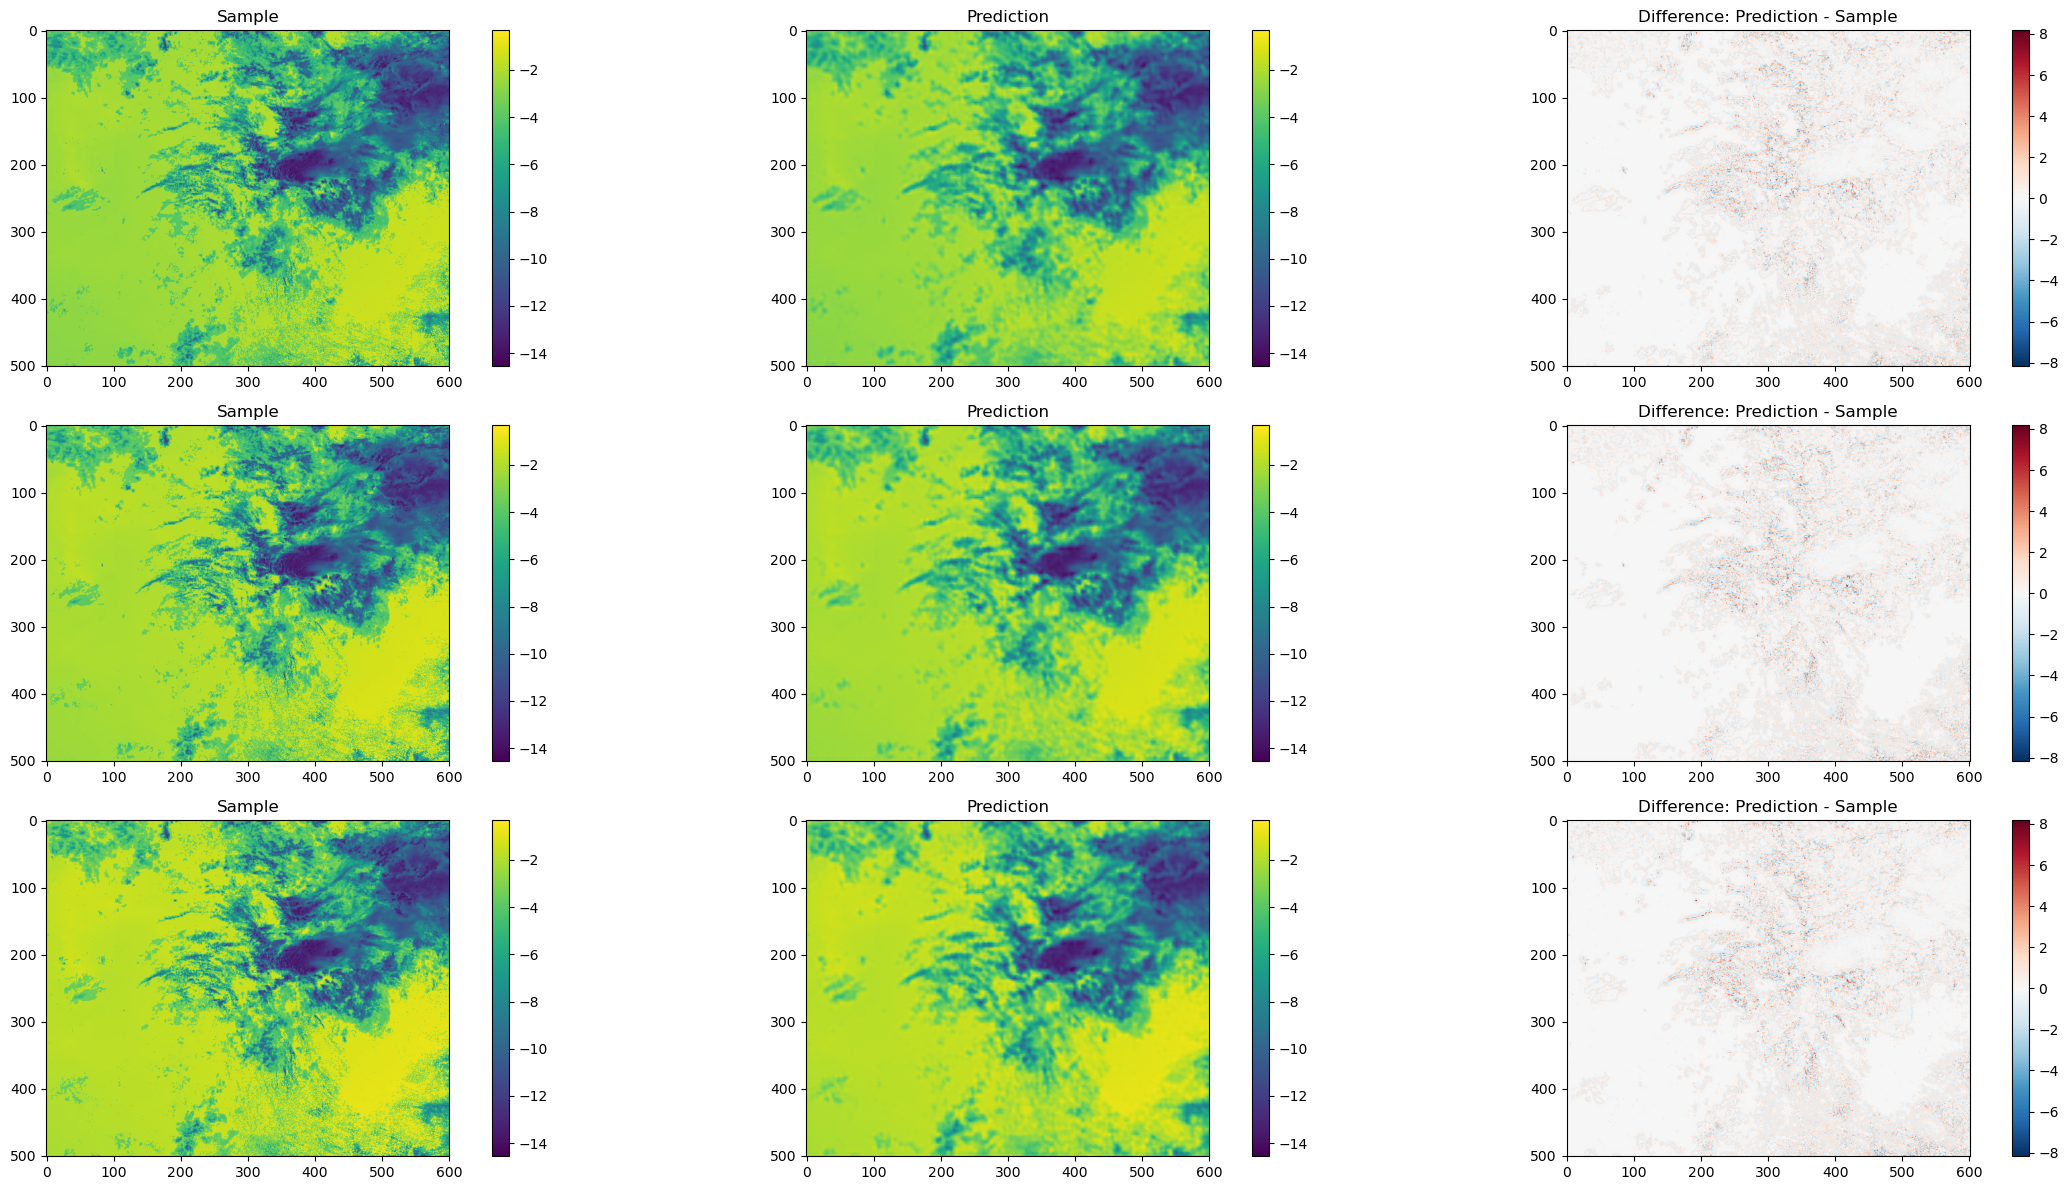

In [11]:
plot_autoencoder_results(model, pipeline = fullsat_test, device='cuda', num_samples= 3)

# Example 2

# Start Fresh
The cell below will clear the checkpoints directory that is used to store vaiours states of your model as it trains later in this notebook.

In [12]:
import shutil
import os

checkpoint_dir = "checkpoints"

if os.path.exists(checkpoint_dir):
    shutil.rmtree(checkpoint_dir)   # deletes the whole folder and its contents
    print(f"Deleted {checkpoint_dir}")

os.makedirs(checkpoint_dir, exist_ok=True)  # recreate empty folder
print("Fresh checkpoint directory ready")

Deleted checkpoints
Fresh checkpoint directory ready


# The Data Pipeline

Here, 2-meter air temperature is extracted from the ERA5 dataset, a global climate reanalysis produced by the European Centre for Medium-Range Weather Forecasts (ECMWF). ERA5 combines historical weather observations with a weather model to provide a consistent, high-resolution representation of the Earth’s atmosphere over time.

In [5]:
training_data = petpipe.Pipeline(
    petdata.archive.ERA5("2t"),
    petdata.transforms.coordinates.StandardLongitude(type="-180-180"),
    petpipe.operations.xarray.normalisation.MagicNorm(cache_dir = checkpoint_dir),
    petpipe.operations.xarray.conversion.ToNumpy(),
    petpipe.operations.numpy.reshape.Rearrange('c t h w -> t c h w'),
    iterator=pyearthtools.pipeline.iterators.DateRange('19990101T00', '20000301T00', interval='6 hours'),
    exceptions_to_ignore=petdata.exceptions.DataNotFoundError,
)

#validate_start = "2002-01-01T00"
#validate_end = "2016-01-02T00"
validate_data = petpipe.Pipeline(
    petdata.archive.ERA5("2t"),
    petdata.transforms.coordinates.StandardLongitude(type="-180-180"),
    petpipe.operations.xarray.normalisation.MagicNorm(cache_dir = checkpoint_dir),
    petpipe.operations.xarray.conversion.ToNumpy(),
    petpipe.operations.numpy.reshape.Rearrange('c t h w -> t c h w'),
    iterator=pyearthtools.pipeline.iterators.DateRange('20160101T00', '20180101T00', interval='6 hours'),
    exceptions_to_ignore=petdata.exceptions.DataNotFoundError,
)



# Initialisation

In [6]:
model = SimpleAutoEncoder(input_channels=1, layers= 4, height=721, width=1440)

# Training

In [ ]:
%%time
model.fit(train_pipeline = training_data, epochs = 4, val_pipeline= validate_data, batch_size= 16, max_samples = 2000, device='cuda')

# Prediction (numerical representation)

In [9]:
model.predict(pipeline = validate_data, device = 'cuda')

tensor([[[[-0.9159, -0.9943, -0.9963,  ..., -0.6363, -0.4522, -0.2269],
          [-0.9432, -1.0198, -0.9999,  ..., -1.0691, -0.3088, -0.5065],
          [-1.0248, -1.0672, -1.0503,  ..., -1.3397, -1.3056, -0.3962],
          ...,
          [-1.2605, -1.3010, -1.2760,  ..., -1.2290, -1.3860, -0.3255],
          [-1.2504, -1.2152, -1.3103,  ..., -0.9640, -0.4722, -0.8238],
          [-1.2064, -1.2486, -1.2388,  ..., -0.8956, -0.6253, -0.3150]]]])

# Prediction (image)

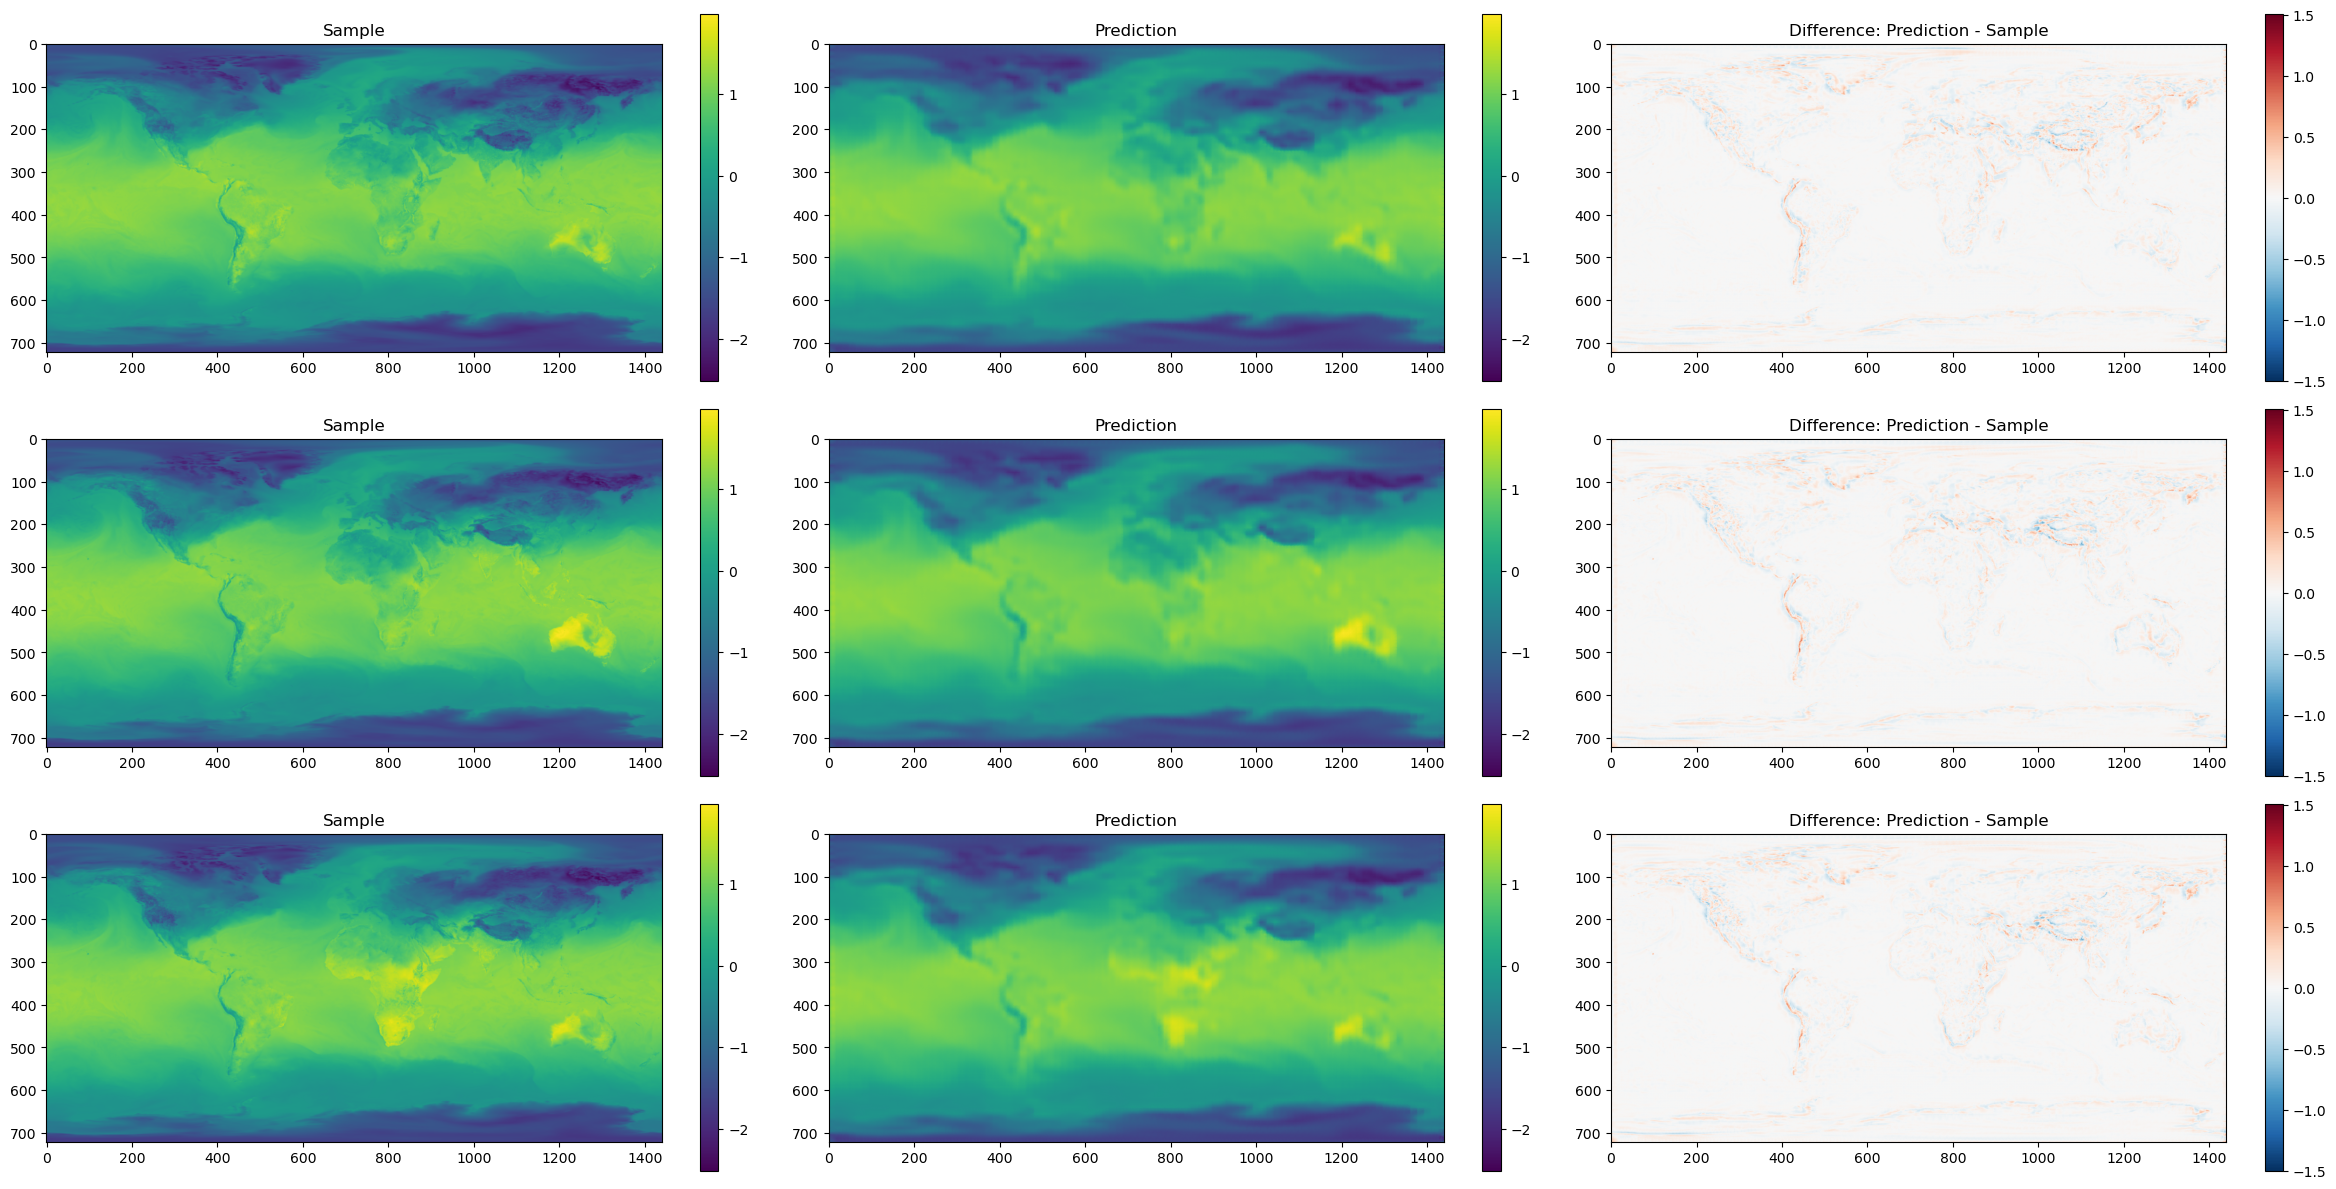

In [10]:
plot_autoencoder_results(model, validate_data, device = 'cuda', num_samples = 3)